In [24]:
from __future__ import annotations

import os
from pathlib import Path

SAM_CKPT = Path('/home/nebula/xxy/dataset/models/sam_vit_h_4b8939.pth')
YOLO_CKPT = Path('/home/nebula/xxy/dataset/models/yolov8l-world.pt')

# 默认：ScanNet200 mv_fast 彩色图（数量极多，下面只抽 N_IMAGES 张）
IMAGE_GLOB = '/home/nebula/xxy/dataset/data/scannet200-mv_fast/2D/*/color/*.jpg'
N_IMAGES = 12

OUT_DIR = Path('/home/nebula/xxy/3D_Reconstruction/test/_sam_overseg_outputs_v2')
OUT_DIR.mkdir(parents=True, exist_ok=True)

print('OUT_DIR:', OUT_DIR)
print('SAM_CKPT exists:', SAM_CKPT.exists())
print('YOLO_CKPT exists:', YOLO_CKPT.exists())

OUT_DIR: /home/nebula/xxy/3D_Reconstruction/test/_sam_overseg_outputs_v2
SAM_CKPT exists: True
YOLO_CKPT exists: True


In [25]:
import glob
import random

image_paths = sorted(glob.glob(IMAGE_GLOB))
if not image_paths:
    raise FileNotFoundError(f'No images found by glob: {IMAGE_GLOB}')

random.seed(0)
random.shuffle(image_paths)
image_paths = image_paths[:N_IMAGES]

print('Num images:', len(image_paths))
print('Example:', image_paths[0])

Num images: 12
Example: /home/nebula/xxy/dataset/data/scannet200-mv_fast/2D/scene0028_00/color/40.jpg


In [26]:
import sys
import numpy as np
import torch
import cv2
import matplotlib.pyplot as plt

AUTO_INSTALL = False  # 没网时建议保持 False

def ensure_import(module: str, pip_name: str | None = None):
    try:
        __import__(module)
        return True
    except Exception as e:
        print(f'[WARN] import {module} failed: {e}')
        if (not AUTO_INSTALL) or (pip_name is None):
            print(f'Please install: pip install {pip_name or module}')
            return False
        import subprocess
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pip_name])
        __import__(module)
        return True

has_sam = ensure_import('segment_anything', pip_name='git+https://github.com/facebookresearch/segment-anything.git')
has_yolo = ensure_import('ultralytics', pip_name='ultralytics')

print('torch:', torch.__version__)
print('cuda available:', torch.cuda.is_available())
print('device:', 'cuda' if torch.cuda.is_available() else 'cpu')
assert has_sam and has_yolo, 'Missing deps: segment_anything / ultralytics'

torch: 1.13.1
cuda available: True
device: cuda


## Part A — SAM 自动分割（统计 mask 数量）

In [27]:
from segment_anything import sam_model_registry, SamAutomaticMaskGenerator

SAM_AUTO = {
    'points_per_side': 32,
    'pred_iou_thresh': 0.86,
    'stability_score_thresh': 0.92,
    'crop_n_layers': 1,
    'crop_n_points_downscale_factor': 2,
    'min_mask_region_area': 100,
}

sam = sam_model_registry['vit_h'](checkpoint=str(SAM_CKPT))
sam.to(device='cuda' if torch.cuda.is_available() else 'cpu')
mask_generator = SamAutomaticMaskGenerator(sam, **SAM_AUTO)

print('SAM auto params:', SAM_AUTO)

SAM auto params: {'points_per_side': 32, 'pred_iou_thresh': 0.86, 'stability_score_thresh': 0.92, 'crop_n_layers': 1, 'crop_n_points_downscale_factor': 2, 'min_mask_region_area': 100}


mask count: 144


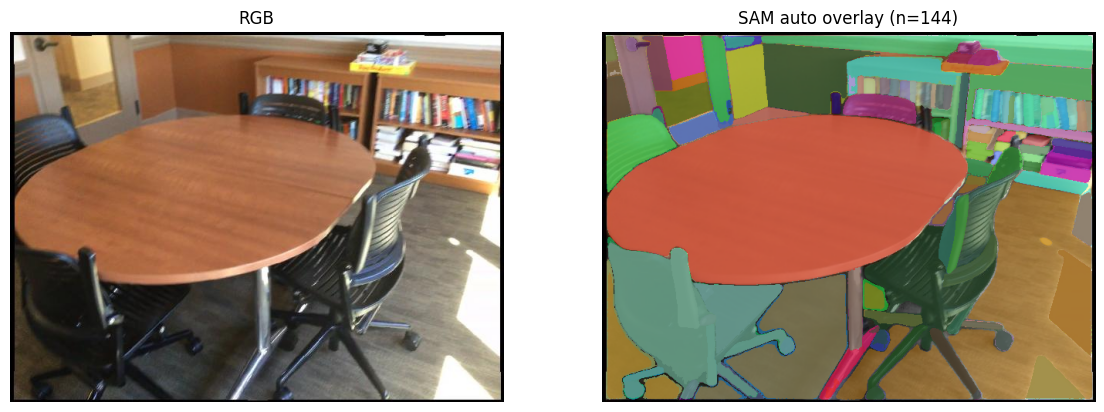

,sam_auto_mask_count,sam_auto_area_mean,sam_auto_area_median,image
0,144,3947.208333,934.0,/home/nebula/xxy/dataset/data/scannet200-mv_fa...
1,80,6350.900000,1433.5,/home/nebula/xxy/dataset/data/scannet200-mv_fa...
2,129,4142.341085,762.0,/home/nebula/xxy/dataset/data/scannet200-mv_fa...
3,133,4767.887218,1435.0,/home/nebula/xxy/dataset/data/scannet200-mv_fa...
4,36,11697.972222,2250.0,/home/nebula/xxy/dataset/data/scannet200-mv_fa...
5,132,4694.613636,589.5,/home/nebula/xxy/dataset/data/scannet200-mv_fa...
6,63,8167.492063,1060.0,/home/nebula/xxy/dataset/data/scannet200-mv_fa...
7,144,3674.576389,882.0,/home/nebula/xxy/dataset/data/scannet200-mv_fa...
8,38,16006.710526,4096.0,/home/nebula/xxy/dataset/data/scannet200-mv_fa...
9,87,6092.770115,720.0,/home/nebula/xxy/dataset/data/scannet200-mv_fa...


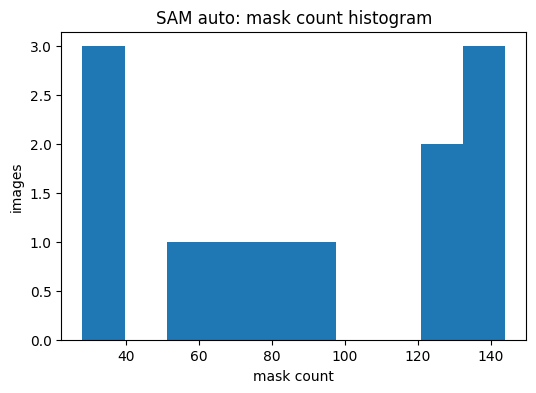

Saved: /home/nebula/xxy/3D_Reconstruction/test/_sam_overseg_outputs_v2/sam_auto_mask_counts.csv
Saved overlays to: /home/nebula/xxy/3D_Reconstruction/test/_sam_overseg_outputs_v2


In [28]:
import pandas as pd

def read_image_bgr(path: str) -> np.ndarray:
    img = cv2.imread(path, cv2.IMREAD_COLOR)
    if img is None:
        raise FileNotFoundError(path)
    return img

def bgr_to_rgb(img_bgr: np.ndarray) -> np.ndarray:
    return cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

def draw_masks_overlay(rgb: np.ndarray, masks: list[dict], alpha: float = 0.55) -> np.ndarray:
    out = rgb.copy()
    rng = np.random.default_rng(0)
    for m in masks:
        seg = m['segmentation']
        color = rng.integers(0, 255, size=(3,), dtype=np.uint8)
        out[seg] = (out[seg] * (1 - alpha) + color * alpha).astype(np.uint8)
    return out

def sam_auto_on_image(path: str):
    bgr = read_image_bgr(path)
    rgb = bgr_to_rgb(bgr)
    masks = mask_generator.generate(rgb)
    areas = [int(m['area']) for m in masks]
    overlay = draw_masks_overlay(rgb, masks)
    return {'path': path, 'count': len(masks), 'areas': areas, 'rgb': rgb, 'overlay': overlay}

# 单张 sanity check（不使用任何嵌套引号 f-string）
demo = sam_auto_on_image(image_paths[0])
print('mask count:', demo['count'])
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1); plt.title('RGB'); plt.imshow(demo['rgb']); plt.axis('off')
plt.subplot(1, 2, 2); plt.title('SAM auto overlay (n={})'.format(demo['count'])); plt.imshow(demo['overlay']); plt.axis('off')
plt.show()

# 批量统计 + 保存 overlay
rows = []
for p in image_paths:
    res = sam_auto_on_image(p)
    rows.append({
        'image': p,
        'sam_auto_mask_count': res['count'],
        'sam_auto_area_mean': float(np.mean(res['areas'])) if res['areas'] else 0.0,
        'sam_auto_area_median': float(np.median(res['areas'])) if res['areas'] else 0.0,
    })
    out_path = OUT_DIR / ('sam_auto_%s.png' % Path(p).stem)
    cv2.imwrite(str(out_path), cv2.cvtColor(res['overlay'], cv2.COLOR_RGB2BGR))

df_auto = pd.DataFrame(rows)
df_auto.to_csv(OUT_DIR / 'sam_auto_mask_counts.csv', index=False)
display(df_auto[['sam_auto_mask_count','sam_auto_area_mean','sam_auto_area_median','image']])

plt.figure(figsize=(6,4))
plt.hist(df_auto['sam_auto_mask_count'].values, bins=10)
plt.title('SAM auto: mask count histogram')
plt.xlabel('mask count')
plt.ylabel('images')
plt.show()

print('Saved:', OUT_DIR / 'sam_auto_mask_counts.csv')
print('Saved overlays to:', OUT_DIR)

## Part B — YOLO→SAM（box prompt）+ 回退/去碎片/去重复

In [36]:
# ====== Part B Setup: YOLO import + params (small-object recall first) ======
import sys
import importlib

BAD_HINTS = [
    "/ESAM/thirdparty/FastSAM",
    "/FastSAM/ultralytics",
]

# 1) 从 sys.path 中移除 FastSAM 相关路径，防止 shadowing
sys.path = [p for p in sys.path if not any(h in (p or "") for h in BAD_HINTS)]

# 2) 清理已加载的 ultralytics 模块缓存（否则还会用旧的）
for name in list(sys.modules.keys()):
    if name == "ultralytics" or name.startswith("ultralytics."):
        del sys.modules[name]

# 3) 导入官方 ultralytics
import ultralytics
print("ultralytics version:", getattr(ultralytics, "__version__", "unknown"))
print("ultralytics file:", ultralytics.__file__)
assert not any(h in ultralytics.__file__ for h in BAD_HINTS), (
    "Still importing vendored ultralytics from FastSAM. Please check PYTHONPATH/sys.path order."
)

# 4) YOLO-World 权重可能需要 dill（你已装过也没关系）
try:
    import dill  # noqa: F401
except ModuleNotFoundError:
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-U", "dill"])
    import dill  # noqa: F401

from ultralytics import YOLO
from segment_anything import SamPredictor

# ====== YOLO 参数：先把召回拉满，再靠后处理收敛 ======
YOLO_CONF = 0.10          # 重点：先降 conf（小物体分数通常低）
YOLO_NMS_IOU = 0.6
YOLO_IMGSZ = 1280         # 重点：提高输入分辨率（小物体更容易被看到）
YOLO_MAX_DET = 300        # 重点：不要在 det 端硬剪到很小
YOLO_AGNOSTIC_NMS = False # class-aware NMS，避免大框压小框

# YOLO-world: 如果你要做闭集/指定类别，写这里；留空则用模型默认
YOLO_CLASSES: list[str] = []  # e.g. ['chair','table','sofa','bed','tv','sink','book']

# ====== box expand ======
BOX_EXPAND_SCALE = 1.10
MIN_WH = 24

# ====== SAM mask selection & fallback ======
FAIL_COV_THRESH = 0.45
FAIL_AREA_NORM_THRESH = 0.25
EDGE_BAND = 4  # px

# ====== postprocess ======
KEEP_TOPK_COMPONENTS = 1
MIN_COMPONENT_AREA_ABS = 300
MIN_COMPONENT_AREA_BOX_FRAC = 0.01
HOLE_AREA_ABS = 300
HOLE_AREA_BOX_FRAC = 0.005

# ====== mask NMS ======
NMS_IOU_THRESH = 0.85
CONTAIN_THRESH = 0.90

# ====== load models ======
yolo = YOLO(str(YOLO_CKPT))
if hasattr(yolo, "set_classes") and len(YOLO_CLASSES) > 0:
    yolo.set_classes(YOLO_CLASSES)
    print("YOLO classes set:", YOLO_CLASSES)

predictor = SamPredictor(sam)

print(
    "YOLO_CONF:", YOLO_CONF,
    "YOLO_NMS_IOU:", YOLO_NMS_IOU,
    "imgsz:", YOLO_IMGSZ,
    "max_det:", YOLO_MAX_DET,
    "agnostic_nms:", YOLO_AGNOSTIC_NMS
)

ultralytics version: 8.3.248
ultralytics file: /home/nebula/miniconda3/envs/ESAM/lib/python3.8/site-packages/ultralytics/__init__.py
YOLO_CONF: 0.1 YOLO_NMS_IOU: 0.6 imgsz: 1280 max_det: 300 agnostic_nms: False


In [37]:
def expand_box_xyxy(box: np.ndarray, w: int, h: int, scale: float, min_wh: int) -> np.ndarray:
    x1, y1, x2, y2 = box.astype(np.float32)
    cx = 0.5 * (x1 + x2)
    cy = 0.5 * (y1 + y2)
    bw = max(float(x2 - x1), float(min_wh)) * scale
    bh = max(float(y2 - y1), float(min_wh)) * scale
    nx1 = max(0.0, cx - 0.5 * bw)
    ny1 = max(0.0, cy - 0.5 * bh)
    nx2 = min(float(w - 1), cx + 0.5 * bw)
    ny2 = min(float(h - 1), cy + 0.5 * bh)
    return np.array([nx1, ny1, nx2, ny2], dtype=np.float32)

def mask_iou(a: np.ndarray, b: np.ndarray) -> float:
    inter = float(np.logical_and(a, b).sum())
    union = float(np.logical_or(a, b).sum())
    return 0.0 if union <= 0 else inter / union

def mask_contain(a: np.ndarray, b: np.ndarray) -> float:
    inter = float(np.logical_and(a, b).sum())
    aa = float(a.sum())
    bb = float(b.sum())
    m = min(aa, bb)
    return 0.0 if m <= 0 else inter / m

def edge_touch_ratio(mask: np.ndarray, box: np.ndarray, band: int) -> float:
    x1, y1, x2, y2 = box.astype(int)
    x1 = max(0, x1); y1 = max(0, y1)
    x2 = max(x1 + 1, x2); y2 = max(y1 + 1, y2)
    m = mask[y1:y2, x1:x2]
    area = float(m.sum())
    if area <= 0 or m.size == 0:
        return 0.0
    b = min(band, (y2 - y1) // 2, (x2 - x1) // 2)
    if b <= 0:
        return 0.0
    border = np.zeros_like(m, dtype=bool)
    border[:b, :] = True
    border[-b:, :] = True
    border[:, :b] = True
    border[:, -b:] = True
    touch = float(np.logical_and(m, border).sum())
    return touch / area

def select_best_mask(masks: np.ndarray, pred_ious: np.ndarray, box: np.ndarray) -> tuple[np.ndarray, dict]:
    x1, y1, x2, y2 = box
    box_area = max(1.0, float((x2 - x1) * (y2 - y1)))
    best_k = 0
    best_info = None
    best_score = -1e9
    for k in range(masks.shape[0]):
        m = masks[k]
        area = float(m.sum())
        if area <= 0:
            continue
        bx1, by1, bx2, by2 = box.astype(int)
        bx1 = max(0, bx1); by1 = max(0, by1)
        bx2 = max(bx1 + 1, bx2); by2 = max(by1 + 1, by2)
        inter = float(m[by1:by2, bx1:bx2].sum())
        cov = inter / box_area
        area_norm = area / box_area
        et = edge_touch_ratio(m, box, EDGE_BAND)
        score = 0.55 * float(pred_ious[k]) + 0.25 * cov + 0.20 * area_norm - 0.30 * et
        info = {'pred_iou': float(pred_ious[k]), 'cov': cov, 'area_norm': area_norm, 'edge_touch': et, 'score': score}
        if score > best_score:
            best_score = score
            best_k = k
            best_info = info
    assert best_info is not None
    return masks[best_k], best_info

def postprocess_mask(mask: np.ndarray, box: np.ndarray) -> tuple[np.ndarray, dict]:
    m = (mask.astype(np.uint8) * 255)
    x1, y1, x2, y2 = box
    box_area = max(1.0, float((x2 - x1) * (y2 - y1)))
    min_area = int(max(MIN_COMPONENT_AREA_ABS, MIN_COMPONENT_AREA_BOX_FRAC * box_area))

    num, labels, stats, _ = cv2.connectedComponentsWithStats((m > 0).astype(np.uint8), connectivity=8)
    comps = [(int(stats[i, cv2.CC_STAT_AREA]), i) for i in range(1, num)]
    comps.sort(reverse=True)

    kept = []
    for area, idx in comps:
        if area < min_area:
            continue
        kept.append(idx)
        if len(kept) >= KEEP_TOPK_COMPONENTS:
            break

    cleaned = np.zeros_like(m, dtype=np.uint8)
    for idx in kept:
        cleaned[labels == idx] = 255

    hole_area = int(max(HOLE_AREA_ABS, HOLE_AREA_BOX_FRAC * box_area))
    inv = (cleaned == 0).astype(np.uint8) * 255
    ff = inv.copy()
    hh, ww = ff.shape
    mask_ff = np.zeros((hh + 2, ww + 2), np.uint8)
    cv2.floodFill(ff, mask_ff, (0, 0), 0)
    holes = (ff > 0).astype(np.uint8)
    numh, labelh, statsh, _ = cv2.connectedComponentsWithStats(holes, connectivity=8)
    fill = np.zeros_like(holes)
    for i in range(1, numh):
        a = int(statsh[i, cv2.CC_STAT_AREA])
        if a <= hole_area:
            fill[labelh == i] = 1
    filled = cleaned.copy()
    filled[fill > 0] = 255

    out = (filled > 0)
    return out, {'components_before': max(0, num - 1), 'components_kept': len(kept), 'min_component_area': min_area}

def mask_nms(instances: list[dict]) -> tuple[list[dict], int]:
    if not instances:
        return [], 0
    order = sorted(range(len(instances)), key=lambda i: instances[i]['det_conf'] * instances[i]['mask_score'], reverse=True)
    keep_idx = []
    suppressed = 0
    for idx in order:
        cand = instances[idx]
        ok = True
        for j in keep_idx:
            ref = instances[j]
            if cand['cls'] != ref['cls']:
                continue
            iou = mask_iou(cand['mask'], ref['mask'])
            contain = mask_contain(cand['mask'], ref['mask'])
            if iou > NMS_IOU_THRESH or contain > CONTAIN_THRESH:
                ok = False
                suppressed += 1
                break
        if ok:
            keep_idx.append(idx)
    return [instances[i] for i in keep_idx], suppressed

def yolo_predict(rgb: np.ndarray, debug: bool = False):
    """
    注意：ultralytics.YOLO.predict() 返回的 boxes 已经是
    after (conf threshold + NMS + max_det) 的结果。
    """
    res = yolo.predict(
        rgb,
        conf=YOLO_CONF,
        iou=YOLO_NMS_IOU,
        imgsz=YOLO_IMGSZ,
        max_det=YOLO_MAX_DET,
        agnostic_nms=YOLO_AGNOSTIC_NMS,
        verbose=False,
    )[0]
    boxes = res.boxes
    if boxes is None or len(boxes) == 0:
        if debug:
            print("YOLO dets(after conf+nms+max_det): 0")
        return (
            np.zeros((0, 4), np.float32),
            np.zeros((0,), np.float32),
            np.zeros((0,), np.int64),
            getattr(res, "names", {}),
        )

    xyxy = boxes.xyxy.detach().cpu().numpy().astype(np.float32)
    conf = boxes.conf.detach().cpu().numpy().astype(np.float32)
    cls = boxes.cls.detach().cpu().numpy().astype(np.int64)

    if debug:
        print("YOLO dets(after conf+nms+max_det):", int(len(xyxy)))
        q = np.quantile(conf, [0.0, 0.25, 0.5, 0.75, 1.0])
        print("conf quantiles:", q)

    return xyxy, conf, cls, getattr(res, "names", {})

def sample_negative_points(box: np.ndarray, coarse_mask: np.ndarray, k: int = 3) -> np.ndarray:
    x1, y1, x2, y2 = box.astype(int)
    x1 = max(0, x1); y1 = max(0, y1)
    x2 = max(x1 + 2, x2); y2 = max(y1 + 2, y2)
    candidates = [(x1 + 5, y1 + 5), (x2 - 5, y1 + 5), (x1 + 5, y2 - 5), (x2 - 5, y2 - 5)]
    negs = []
    for x, y in candidates:
        x = int(np.clip(x, x1, x2 - 1)); y = int(np.clip(y, y1, y2 - 1))
        if not coarse_mask[y, x]:
            negs.append([x, y])
        if len(negs) >= k:
            break
    if len(negs) < k:
        ys, xs = np.where(~coarse_mask[y1:y2, x1:x2])
        if len(xs) > 0:
            idx = np.random.choice(len(xs), size=min(k - len(negs), len(xs)), replace=False)
            for ii in idx:
                negs.append([int(x1 + xs[ii]), int(y1 + ys[ii])])
    return np.array(negs, dtype=np.float32) if negs else np.zeros((0, 2), dtype=np.float32)

def sam_segment_from_box(rgb: np.ndarray, boxes_xyxy: np.ndarray, confs: np.ndarray, clses: np.ndarray):
    H, W = rgb.shape[:2]
    predictor.set_image(rgb)
    instances = []
    fallback_used = 0
    comps_total = 0
    for box, det_conf, cls_id in zip(boxes_xyxy, confs, clses):
        ebox = expand_box_xyxy(box, W, H, BOX_EXPAND_SCALE, MIN_WH)
        masks, scores, _ = predictor.predict(box=ebox, multimask_output=True)
        best_mask, info = select_best_mask(masks, scores, ebox)
        need_fb = (info['cov'] < FAIL_COV_THRESH) or (info['area_norm'] < FAIL_AREA_NORM_THRESH)
        if need_fb:
            cx = 0.5 * (ebox[0] + ebox[2]); cy = 0.5 * (ebox[1] + ebox[3])
            pos = np.array([[cx, cy]], dtype=np.float32)
            neg = sample_negative_points(ebox, best_mask, k=3)
            pts = np.concatenate([pos, neg], axis=0)
            labels = np.array([1] + [0] * len(neg), dtype=np.int32)
            masks2, scores2, _ = predictor.predict(box=ebox, point_coords=pts, point_labels=labels, multimask_output=True)
            best2, info2 = select_best_mask(masks2, scores2, ebox)
            if info2['score'] > info['score']:
                best_mask, info = best2, info2
            fallback_used += 1
        best_mask, pp = postprocess_mask(best_mask, ebox)
        comps_total += pp['components_before']
        instances.append({'mask': best_mask, 'box': ebox, 'det_conf': float(det_conf), 'cls': int(cls_id), 'mask_score': float(info['pred_iou']), 'cov': float(info['cov']), 'area_norm': float(info['area_norm']), 'edge_touch': float(info['edge_touch']), 'score': float(info['score'])})
    kept, suppressed = mask_nms(instances)
    metrics = {'num_det': int(len(instances)), 'num_kept': int(len(kept)), 'suppressed': int(suppressed), 'dup_rate': float(suppressed / max(1, len(instances))), 'fallback_used': int(fallback_used), 'fallback_rate': float(fallback_used / max(1, len(instances))), 'avg_components_per_mask': float(comps_total / max(1, len(instances)))}
    return kept, metrics

def draw_instances(rgb: np.ndarray, instances: list[dict], names: dict | None = None, alpha: float = 0.55) -> np.ndarray:
    out = rgb.copy()
    rng = np.random.default_rng(123)
    for inst in instances:
        m = inst['mask']
        color = rng.integers(0, 255, size=(3,), dtype=np.uint8)
        out[m] = (out[m] * (1 - alpha) + color * alpha).astype(np.uint8)
        x1, y1, x2, y2 = inst['box'].astype(int)
        cv2.rectangle(out, (x1, y1), (x2, y2), (255, 0, 0), 2)
        label = str(inst['cls'])
        if names is not None and int(inst['cls']) in names:
            label = names[int(inst['cls'])]
        cv2.putText(out, ('%s:%.2f' % (label, inst['det_conf'])), (x1, max(0, y1 - 6)), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 1, cv2.LINE_AA)
    return out

YOLO dets(after conf+nms+max_det): 7
conf quantiles: [    0.12267       0.173     0.44526     0.62587     0.78213]
Image: /home/nebula/xxy/dataset/data/scannet200-mv_fast/2D/scene0028_00/color/40.jpg
Det count(after conf+nms+max_det): 7
Metrics: {'num_det': 7, 'num_kept': 6, 'suppressed': 1, 'dup_rate': 0.14285714285714285, 'fallback_used': 3, 'fallback_rate': 0.42857142857142855, 'avg_components_per_mask': 1.8571428571428572}


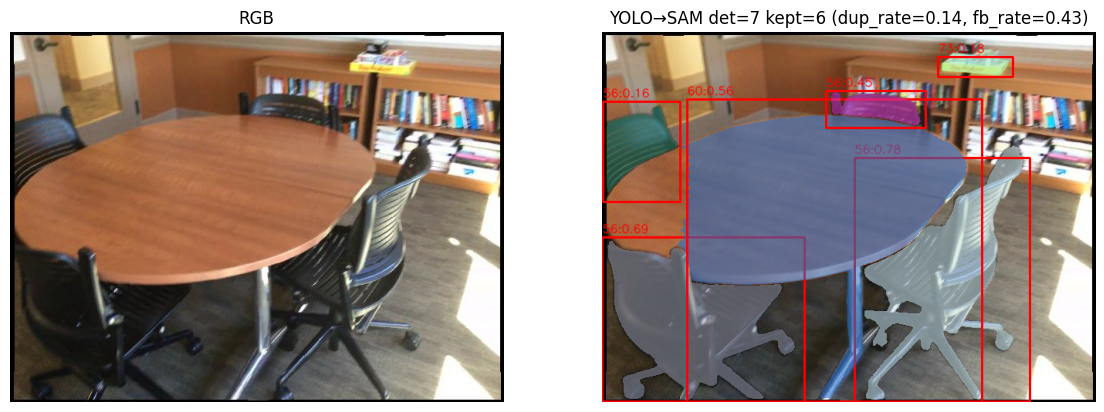

Saved: /home/nebula/xxy/3D_Reconstruction/test/_sam_overseg_outputs_v2/yolo_sam_40.png


In [38]:
path = image_paths[0]
rgb = bgr_to_rgb(read_image_bgr(path))

boxes, confs, clses, names = yolo_predict(rgb, debug=True)
kept, metrics = sam_segment_from_box(rgb, boxes, confs, clses)
overlay = draw_instances(rgb, kept, names=names)

print("Image:", path)
print("Det count(after conf+nms+max_det):", int(len(boxes)))
print("Metrics:", metrics)

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1); plt.title("RGB"); plt.imshow(rgb); plt.axis("off")
plt.subplot(
    1, 2, 2
); plt.title(
    "YOLO→SAM det={} kept={} (dup_rate={:.2f}, fb_rate={:.2f})".format(
        metrics["num_det"], metrics["num_kept"], metrics["dup_rate"], metrics["fallback_rate"]
    )
); plt.imshow(overlay); plt.axis("off")
plt.show()

out_path = OUT_DIR / ("yolo_sam_%s.png" % Path(path).stem)
cv2.imwrite(str(out_path), cv2.cvtColor(overlay, cv2.COLOR_RGB2BGR))
print("Saved:", out_path)

,sam_auto_mask_count,num_det,num_kept,dup_rate,fallback_rate,avg_components_per_mask,image
0,144,7,6,0.142857,0.428571,1.857143,/home/nebula/xxy/dataset/data/scannet200-mv_fa...
1,80,11,10,0.090909,0.272727,1.181818,/home/nebula/xxy/dataset/data/scannet200-mv_fa...
2,129,9,8,0.111111,0.222222,13.111111,/home/nebula/xxy/dataset/data/scannet200-mv_fa...
3,133,6,5,0.166667,0.333333,4.000000,/home/nebula/xxy/dataset/data/scannet200-mv_fa...
4,36,3,3,0.000000,0.000000,1.000000,/home/nebula/xxy/dataset/data/scannet200-mv_fa...
5,132,7,6,0.142857,0.000000,1.857143,/home/nebula/xxy/dataset/data/scannet200-mv_fa...
6,63,5,4,0.200000,0.000000,1.200000,/home/nebula/xxy/dataset/data/scannet200-mv_fa...
7,144,7,7,0.000000,0.428571,4.000000,/home/nebula/xxy/dataset/data/scannet200-mv_fa...
8,38,2,2,0.000000,0.500000,1.000000,/home/nebula/xxy/dataset/data/scannet200-mv_fa...
9,87,6,5,0.166667,0.000000,1.166667,/home/nebula/xxy/dataset/data/scannet200-mv_fa...


Saved: /home/nebula/xxy/3D_Reconstruction/test/_sam_overseg_outputs_v2/yolo_sam_metrics.csv


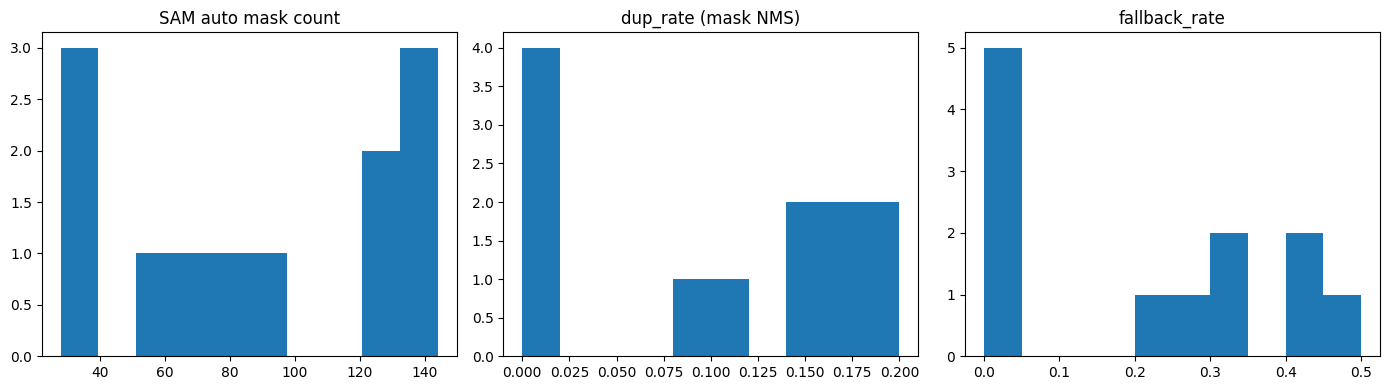

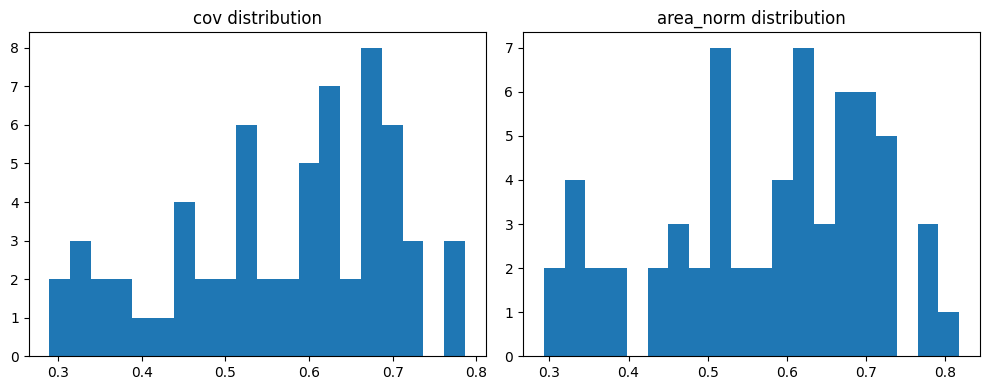

In [32]:
rows = []
all_cov = []
all_area_norm = []

for p in image_paths:
    rgb = bgr_to_rgb(read_image_bgr(p))
    auto = sam_auto_on_image(p)
    boxes, confs, clses, names = yolo_predict(rgb)
    kept, metrics = sam_segment_from_box(rgb, boxes, confs, clses)
    for inst in kept:
        all_cov.append(inst['cov'])
        all_area_norm.append(inst['area_norm'])
    overlay = draw_instances(rgb, kept, names=names)
    cv2.imwrite(str(OUT_DIR / ('yolo_sam_%s.png' % Path(p).stem)), cv2.cvtColor(overlay, cv2.COLOR_RGB2BGR))
    rows.append({'image': p, 'sam_auto_mask_count': int(auto['count']), **metrics})

df = pd.DataFrame(rows)
df.to_csv(OUT_DIR / 'yolo_sam_metrics.csv', index=False)
display(df[['sam_auto_mask_count','num_det','num_kept','dup_rate','fallback_rate','avg_components_per_mask','image']])
print('Saved:', OUT_DIR / 'yolo_sam_metrics.csv')

plt.figure(figsize=(14,4))
plt.subplot(1,3,1); plt.hist(df['sam_auto_mask_count'].values, bins=10); plt.title('SAM auto mask count')
plt.subplot(1,3,2); plt.hist(df['dup_rate'].values, bins=10); plt.title('dup_rate (mask NMS)')
plt.subplot(1,3,3); plt.hist(df['fallback_rate'].values, bins=10); plt.title('fallback_rate')
plt.tight_layout(); plt.show()

plt.figure(figsize=(10,4))
plt.subplot(1,2,1); plt.hist(np.asarray(all_cov), bins=20); plt.title('cov distribution')
plt.subplot(1,2,2); plt.hist(np.asarray(all_area_norm), bins=20); plt.title('area_norm distribution')
plt.tight_layout(); plt.show()

## 你该怎么肉眼检查（建议）\n
- **SAM auto overlay**：看是否出现大量细碎小片/同一物体被切成很多块（mask 数量异常大）。\n
- **YOLO→SAM overlay**：看同一物体是否仍被多个实例重复抠（dup_rate 高），或经常只抠到局部（cov/area_norm 低）。\n
- 如果 fallback_rate 很高：优先检查 YOLO 框是否过紧/漏检，然后调 `BOX_EXPAND_SCALE`。\n
- 如果 dup_rate 很高：检查 `YOLO_NMS_IOU` 与 `NMS_IOU_THRESH/CONTAIN_THRESH`。